In [1]:
import sys, os
sys.path.insert(0, '../utils')


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from connectome_types import CALCIUM_H5_PATH
from utils import load_neurons_table
from sk_load_utils import load_col_skeleton_only
from activity_utils import (require_activity_h5, load_ex_functional_data_by_root_id,
                            select_scan_matrix, slice_window)
from plot_utils import ex_color, inh_color, ei_palette
from figure7_utils import plot_figure7_with_data

# Synapse-target colours, as in figure 4.
spiny_color = '#7C3AED'
aspiny_color = '#059669'


In [3]:
# ── what this figure needs, checked up front ─────────────────────────────────
# Panel E draws four deconvolved calcium traces, so this notebook needs the MICrONS
# calcium H5. It is not in the Zenodo snapshot — build it once with
# scripts/extract_calcium_data_via_docker.ipynb inside the MICrONS database container.
# Panels A–D and F are schematics plus the column skeletons, and need none of it.
require_activity_h5(CALCIUM_H5_PATH, needed_by='figure 7 panel E')

In [4]:

# ---- figure-wide ink: the axons ----
# The grey an axon is drawn in where it is *wiring* rather than a cell: panel d's
# projecting axons, which leave the figure and belong to nobody on it. Grey
# rather than a cell's own ink because the red and the blue are reserved for the
# cells themselves, and a grey line does not compete with either.
# Panel c goes the other way — there the axons *are* the subject, so each one
# takes the sending cell's own color (see `AXON_KW` / `INH_ARROW_KW` below).
# Set once here so every panel that wants the grey takes it from the same place;
# the two are kept apart so the inhibitory wiring can be pulled off the
# excitatory later without touching panel d.

# ---- panel B (spiny/aspiny) — every knob for both parts lives here ----

# shape + ink, shared by both cells
# `spine_len` sizes the whole traced spine, head included, so it is really the
# head knob; `neck_ext` adds length to the neck alone. The spine stands
# spine_len + neck_ext off the dendrite with the head it had at spine_len —
# which is how it pops out without the heads growing into each other on the
# densely spined apical.
NEURON_KW = dict(
    trunk_len=1.80, spine_len=0.21, neck_ext=0.04, tube_w=0.11, tube_taper=0.72,
    basal_angle_deg=40, soma_round=5, soma_neck_r=0.25,
    soma_bow_bottom=0.02, soma_bow_side=-0.005,
    # fill_color=None washes the interior with the cell's own ink, at
    # figure7_utils.NEURON_FILL_ALPHA - left to the module so every cell on the
    # figure, down to the small ones panel d and the column draw, is washed to
    # the same strength. Change it there, not here. A `fill_alpha` in this dict
    # would override it for these cells alone; 'white' goes back to hollow.
    edge_color=ex_color, fill_color=None, wall_lw=1.0, alpha=1.0,
)

# the only difference between the two cells: how many spines, on every branch
SPINY_KW  = dict(n_spines=8, basal_spines=5)
ASPINY_KW = dict(n_spines=3, basal_spines=1)

# synapse dots — style shared, counts per cell
DOT_KW = dict(
    spiny_color=spiny_color, aspiny_color=aspiny_color,
    dot_size=34, dot_alpha=1.0, dot_edge_color='none', dot_edge_lw=0.0,
    spine_gap=0.01, shaft_gap=0.01, soma_gap=0.02,   # clearance off the wall
)
# n_spine / n_shaft take a total to share out, one count per branch —
# (apical, basal left, basal right) — or 'all'. Each branch splits its own share
# between its two walls, so the dots never all stack on one side of the dendrite.
# Spines are dotted with 'all' on both cells: a drawn spine head with no dot on
# it reads as a spine that receives nothing, which is not what this panel says.
# The contrast is then carried by the spine counts above — the left cell has
# more spines, so it ends up with more synapses, which is the point.
SPINY_DOTS  = dict(n_spine='all', n_shaft=3, n_soma=2)   # loaded apical
ASPINY_DOTS = dict(n_spine='all', n_shaft=3, n_soma=1)   # fewer spines, fewer dots

# layout: `spacing` is the gap between the two cell centres — shrink it and the
# left cell's basal leg runs into the right cell's.
# `pad` is the margin the axes are fitted with, in the same local units. On the
# combined figure the axes box fills its grid cell whatever it holds, so padding
# is what sets how big the *cells* come out inside it: raise it and they shrink.
PAIR_KW = dict(spacing=3.7, pad=0.55, figsize=(6.6, 4.4), dpi=150)


# ---- panel A (ex/inh) — the same spiny cell, now against an inhibitory one ----

# left cell: panel B's spiny one, unchanged, and its dots unchanged with it
EX_KW   = dict(NEURON_KW, **SPINY_KW)
EX_DOTS = SPINY_DOTS

# right cell: shape + ink of the inhibitory cell — no apical, no basals, four
# arms off a soma between a circle and a square, and no spines anywhere
INH_KW = dict(
    branch_len=1.05, branch_angle_deg=45,
    soma_w=0.42, soma_h=0.40, soma_squareness=3.4,
    tube_w=0.11, tube_taper=0.72,
    edge_color=inh_color, fill_color=None, wall_lw=1.0, alpha=1.0,   # as above
)

# its dots: one color (aspiny green) — with no spines, shaft and soma are all
# there is to land on — and about twice as many as the pyramidal cell carries
INH_DOT_KW = dict(
    color=aspiny_color,
    dot_size=36, dot_alpha=1.0, dot_edge_color='none', dot_edge_lw=0.0,
    shaft_gap=0.012, soma_gap=0.02,     # clearance off the wall
    shaft_t_range=(0.10, 0.96),  # how far along an arm dots may sit
    n_shaft_cand=9,        # candidate sites per wall, per arm — the crowding
    shaft_stagger=0.5,     # offset between the two walls, in candidate steps
    soma_skip_deg=26,      # ring sector at each arm that is not soma any more
)
# n_shaft is a total over the four arms, or one count per arm. Both are capped
# by the candidates above (4 arms × 2 walls × n_shaft_cand, and the free ring),
# so asking for more than there is room for just fills every site.
INH_DOTS = dict(n_shaft=42, n_soma=8)

# layout: `inh_scale` sizes the four-armed cell against the pyramidal one,
# `inh_dy` nudges it off the centre of the pyramidal cell's drawn height
EX_INH_KW = dict(spacing=3.7, inh_scale=1.45, inh_dy=0.0, pad=0.55,
                 figsize=(6.6, 4.4), dpi=150)


# ---- each panel's full call, assembled once ----
# The cells below draw them one at a time and the combined figure at the end of the
# notebook draws them again on one canvas, from these same dicts — so a knob
# turned above lands in both. `figsize` / `dpi` are ignored on the shared canvas.
PANEL_B_KW = dict(neuron_kw=NEURON_KW, spiny_kw=SPINY_KW, aspiny_kw=ASPINY_KW,
                  with_synapses=True, dot_kw=DOT_KW,
                  spiny_dots=SPINY_DOTS, aspiny_dots=ASPINY_DOTS, **PAIR_KW)

PANEL_A_KW = dict(ex_kw=EX_KW, inh_kw=INH_KW,
                  with_synapses=True, dot_kw=DOT_KW, ex_dots=EX_DOTS,
                  inh_dot_kw=INH_DOT_KW, inh_dots=INH_DOTS, **EX_INH_KW)


In [5]:
# ---- panel C config — every knob for both parts lives here ----

# part 1: the four excitatory cells. `NEURON_KW` is the standard cell from
# panel B; the row all shares it, so they come out identical.
CIRCUIT_EX_KW = dict(NEURON_KW, n_spines=6, basal_spines=3)

# layout, in local units: even pitch, and each cell at its own height — they
# are deliberately not on one baseline, which is what lets the axons run at
# readable angles instead of all lying flat along the row
# neuron 4 sits well above neuron 3 on purpose: its axon drops `axon_drop` out
# of the soma before it turns, and only from up there does the turn leave it
# level with the apical spine on 3 it has to reach — any lower and the 4->3 leg
# has to climb back up, which reads as the wrong direction of travel
CIRCUIT_LAYOUT = dict(spacing=3.50, ex_dy=(0.0, -1.10, -0.10, 1.30))

# who wires to whom, cells numbered 1-4 left to right
CONNECTIONS = ((1, 2), (1, 3), (3, 2), (3, 4), (4, 3))

# the axons: thin lines, soma -> spine, arcing over the row
AXON_KW = dict(
    # each axon in the sending cell's own ink rather than the figure-wide grey:
    # this panel is about who wires to whom, so the line carries the identity of
    # the cell it leaves — panel d's projecting axon is inked to match
    axon_color=ex_color, axon_lw=0.5, axon_alpha=1.0,
    axon_drop=0.95,              # straight down out of the soma first, then
                                 # turn — has to clear the soma's bottom edge
    axon_rad=-0.05,              # how far an axon bows off straight; + = up.
                                 # A hair negative carries the drop on into the
                                 # run — bow it up and the line turns straight
                                 # back where it came from
    axon_smooth=0.25,            # how wide the turn out of the drop is, as a
                                 # fraction of the run left to the target — the
                                 # axon is one stroke, so this rounds the corner
                                 # instead of leaving the two pieces meeting at
                                 # an angle. Much higher and 1->2 and 1->3 dive
                                 # far enough on the way out to cross each other
    axon_rads={(4, 3): 0.10},    # 3<->4 is reciprocal — bow the return leg the
                                 # other way or the two arcs sit on top of each
                                 # other. Small: 4->3 runs nearly level, and it
                                 # wants a hint of a curve, not a loop
    axon_forks={1: 0.50},        # how far along its stem a cell with two
                                 # outputs splits, as a fraction of the way to
                                 # its targets' centroid. Cell 1 forks late: at
                                 # the default 0.40 the branch heading for 2
                                 # leaves while still short of 2's own basal and
                                 # has to climb across it to reach the apical.
                                 # Carrying the stem on past that tip first puts
                                 # the split in the open ground between the two
                                 # cells, and the branch rises clear of
                                 # everything. Much later and it comes up behind
                                 # 2's soma instead, which reads as leaving it
    spine_rank=None,             # {(pre, post): k} to step off the default spine
    spine_branch={(1, 2): 'apical', (4, 3): 'apical'},   # pin a contact to a
                                 # compartment — nearest-first would otherwise
                                 # always find a basal, those being what an axon
                                 # coming along the row passes closest to. Which
                                 # is exactly what 1->2 was doing: the two cells
                                 # nearly touch basal to basal, so the contact
                                 # sat in that thicket. On the proximal apical it
                                 # is out in the open, and the axon has somewhere
                                 # to run to get there
)

# the synapse at the end of each axon — a plain purple dot, as in panel A
CIRCUIT_SYN_KW = dict(
    syn_color=spiny_color, syn_size=36, syn_alpha=1.0,
    syn_edge_color='none', syn_edge_lw=0.0,
    syn_gap=0.02,                # visible clearance off the spine head
)

# part 2: the inhibitory cell above the row — panel B's cell, unchanged
CIRCUIT_INH_KW = dict(
    INH_KW,
    wall_lw=0.8,                 # same weight as its own connectors below
    # `inh_dy` is the *gap* between the top of the row and the bottom of this
    # cell, not its centre, so resizing it doesn't push it into the row
)
# it is the supporting cast here, not the subject — kept small so the four
# excitatory cells stay the biggest thing in the panel
# `inh_dy` is a gap measured from the top of the row *as a whole*, so it goes
# negative here: the tallest cell is neuron 4 off to the right, and dropping the
# inhibitory cell past that ceiling into the empty space over neurons 2 and 3
# shortens both its connectors and the whole panel
CIRCUIT_INH_PLACE = dict(inh_scale=0.60, inh_dx=0.0, inh_dy=-0.60)

# its four connectors: a flat bar instead of an arrowhead, and a synapse dot
# at the end of each in the colour of whatever it lands on
INH_ARROW_KW = dict(
    inh_targets=(1, 2, 3, 4),    # which cells it contacts
    # what each connector contacts. The two outer cells have open space
    # beside them, so those two go to the soma; the two inner ones are boxed
    # in by their neighbours and take a spine at the top of the apical tuft,
    # which is also where a connector coming down from above arrives anyway.
    # Which compartment it is is the claim this panel is making, so the dot
    # at the end says so in the key's own colours.
    inh_target_kind={1: 'soma', 2: 'spine', 3: 'spine', 4: 'soma'},
    inh_target_t={1: 0.40, 4: 0.40},   # the soma contacts: how far down the
                                 # flank facing the inhibitory cell, 0 just
                                 # under the apex and 1 the bottom corner.
                                 # The spine contacts ignore it — those are
                                 # picked distal-most first (`inh_spine_rank`)
    inh_syn_colors=dict(spine=spiny_color, soma=aspiny_color),
    inh_syn_gap=0.05,            # the dot's visible clearance off the cell,
                                 # in local units. A hair more than the row's
                                 # own `syn_gap`: a soma wall is a bowed and
                                 # rounded outline, so the dot has its bulge
                                 # to clear as well as its linewidth
    inh_line_color=inh_color, inh_lw=0.8, inh_alpha=1.0,   # its own blue, as above
    inh_rad=0.10,                # + bows each branch outward
    # The cell reaches all four the way the row's own cells reach each other:
    # ONE axon out of the bottom of the soma, forking into a branch per target
    # (`_axon_tree`). Four separate connectors read as spokes off a hub — and
    # cells 2 and 3 sit almost directly underneath, so their two lines left the
    # soma collinear and had to be parted by hand. One stem that bifurcates is
    # both the cell's actual anatomy and the shape panel d's arbor is drawn as.
    inh_drop=0.8,                # the shared descent, before anything forks:
                                 # far enough to clear the cell's own arms, so
                                 # the axon reads as leaving the bottom of the
                                 # soma rather than radiating from its middle,
                                 # and short enough to keep the fork up in the
                                 # open air above the row. Units are the
                                 # inhibitory cell's own
    inh_fork=0.15,               # where it splits, as a fraction of the way
                                 # from the foot of that descent to the four
                                 # targets' centroid — high, just under the
                                 # cell, so every branch starts above the row
                                 # and comes *down* onto its target. Fork lower
                                 # and the split lands level with the apicals,
                                 # from where the long branch out to cell 4 has
                                 # to push through cell 3's tuft to get there
    inh_spread=0.35,             # how hard a branch turns off the stem at the
                                 # fork: 0 leaves tangent to it, 1 leaves
                                 # pointing at the target. High for the same
                                 # reason the fork is high — at 0 the branch
                                 # for cell 4 leaves *downward* with the stem
                                 # and has to climb back over cell 3, halving
                                 # its clearance over the tuft (0.4 world units
                                 # against 0.8 here)
    inh_rads={2: -0.05, 3: -0.06, 4: -0.30},   # and how each run bows after
                                 # it. The sign is literal, so negative bows a
                                 # *rightward* branch up: the long run out to
                                 # cell 4 is arched hard enough to pass well
                                 # over cell 3's tuft rather than shaving it.
                                 # The other two are a hair either way, just to
                                 # keep the runs from looking ruled
    inh_bar_width=2.0, inh_bar_length=0.0,   # `-[` arrowstyle: a flat bar
    inh_bar_scale=3.0,           # bar is width x scale points across
    inh_gap=2.0,                 # visible clearance in POINTS, now between
                                 # the bar and the *dot* at the end of its own
                                 # connector rather than the cell — the dot,
                                 # the target's spine envelope and half the
                                 # bar's own length are all accounted for
                                 # underneath it, so the bar stops just short
                                 # of the synapse and the pair reads as one
                                 # contact
)

CIRCUIT_FIG_KW = dict(figsize=(9.5, 5.4), dpi=350)


# the panel's full call — used by the cell below and by the combined figure
PANEL_C_KW = dict(n_ex=4, ex_kw=CIRCUIT_EX_KW, connections=CONNECTIONS,
                  inh_kw=CIRCUIT_INH_KW, with_inh=True,
                  **CIRCUIT_LAYOUT, **AXON_KW, **CIRCUIT_SYN_KW,
                  **CIRCUIT_INH_PLACE, **INH_ARROW_KW, **CIRCUIT_FIG_KW)


In [6]:
# ---- panel D config — every knob for both axons lives here ----

# the cells: the standard cell from panel B, drawn small, hairline and faded.
# It is not the subject here — the axon is — so it is inked just enough to say
# "this axon comes out of a pyramidal cell" and no more. `alpha` fades it by
# blending toward the page (see `plot_ex_neuron`); drop it further to push the
# dendrite back, raise it to bring the cell forward.
PANEL_D_CELL_KW = dict(NEURON_KW, n_spines=6, basal_spines=3,
                       wall_lw=0.65, alpha=0.85)

# layout: the two soma centres, and how big the cells are drawn against the
# axon lengths below. `cell_rotate_deg=0` leaves each cell upright, apical up,
# so its axon leaves *downward* the way a real one does and reaches the rest of
# the panel by dropping clear of the basals and turning a rounded 90° right —
# `plot_axon_panel`'s elbow, sized off `cell_scale`. Override it per axon with
# `elbow_len` / `elbow_r` / `elbow_turn_deg` in `AXON_D_KW` below.
PANEL_D_LAYOUT = dict(cell_scale=0.05, cell_rotate_deg=0,
                      cell_xy=((0.0, 0.0), (0.0, -5.60)))

# the axons: style shared by both, everything that differs is per-axon below
AXON_D_KW = dict(
    # same ink as panel C's cell -> cell axons: `ex_color` at `axon_lw=0.5`,
    # so the projection and the circuit's wiring read as the same process
    color=ex_color, lw=0.5, alpha=1.0,
    collateral_lw=0.75,          # collaterals, x the trunk's linewidth
    spiny_color=spiny_color, aspiny_color=aspiny_color,
    dot_size=24, dot_alpha=1.0, dot_edge_color='none', dot_edge_lw=0.0,
    dot_gap=0.0,                 # 0 centres each dot on its tip — a bouton
    tip_syn=True,                # the trunk's own tip carries one too
)

# per-axon: top cell first. `length` is in the same units as `cell_xy`;
# everything about the branching is a fraction of it, so the short axon is a
# scaled-down version of the long one rather than a stubbier one.
# `spiny_frac` is the share of outputs landing on a spine, `spiny_bias` tilts
# *which* ones toward the distal end (0 = pure shuffle, ~2 = distal wins most
# ties but a couple of proximal ones still slip through), `seed` fixes both
# that draw and the hand-drawn jitter of the branches.
AXON_D_KWS = (
    # top: projects far and *arborises* — a branching tree of comparable
    # branches with many outputs on it, mostly onto spines. The few shaft ones
    # sit proximally (`spiny_bias`), so the tips of the tree read as all spine.
    # `shape='tree'` swaps the axon for `_axon_tree_geometry`; `n_syn` is then
    # the total spread evenly across every branch, not one per collateral tip.
    dict(shape='tree', length=8.60, n_syn=60, spiny_frac=0.80, spiny_bias=1.6,
         seed=3, lw_decay=0.94, syn_first_dist=1.15,
         geom_kw=dict(trunk_frac=0.04, stem_frac=0.6,
                      # `trunk_frac` is the scale of the whole tree, so it
                      # can't shorten the stem on its own — `stem_frac` pulls
                      # the arbor in toward the soma at unchanged size, until
                      # the stem reads as one branch among its children rather
                      # than a long run before them
                      depth=4, n_children=2, first_children=3,
                      spread_deg=40, spread_decay=0.78, angle_jitter=9.0,
                      max_angle_deg=50, child_frac=0.84, len_jitter=0.26,
                      bend=0.05, wave_amp=0.04, wave_n=1.1)),
    # bottom: short, few outputs, half of them onto spines — and the further
    # ones are the spiny ones
    dict(length=3.40, n_syn=6, spiny_frac=0.50, spiny_bias=1.8, seed=7,
         geom_kw=dict(collateral_len=0.20, collateral_angle_deg=55,
                      first_t=0.16, last_t=0.94,
                      wave_amp=0.030, wave_n=1.8, bend=0.020)),
)

# Width matched to panel C so the two line up when stacked. The axes are
# aspect-locked, so the *inked* width is min(fig_w, fig_h · dx/dy). Raise the
# height until dy/dx binds and the drawing fills its cell's width — the tree
# arbor + bottom cell make dy substantial, so this is well over the old value.
PANEL_D_FIG_KW = dict(figsize=(9.5, 6.20), dpi=150)


# the panel's full call — used by the cell below and by the combined figure
PANEL_D_KW = dict(cell_kw=PANEL_D_CELL_KW, axon_kw=AXON_D_KW,
                  axon_kws=AXON_D_KWS, **PANEL_D_LAYOUT, **PANEL_D_FIG_KW)


In [7]:
# ---- assembly config — the ink, the text, the legend, and the grid ----

# Everything quoted in POINTS — line widths, dot areas, font sizes — and so
# does NOT scale when a panel is drawn smaller on the shared canvas than it is
# on its own. Those are the knobs that need retuning after any change to the
# grid, so they are gathered here, per panel, instead of being scattered
# through the panels' own config cells above. Everything else (spacing, gaps,
# `pad`) is in the panels' local units and scales with them on its own.
FIG7_INK = dict(
    a=dict(                      # ex/inh pair, top left
        wall_lw=1.0,             # the pyramidal cell's outline
        inh_wall_lw=1.5,         # the inhibitory cell's outline — heavier
                                 # than the pyramidal one's on purpose: its
                                 # arms are smooth tubes with nothing on them
                                 # but dots, and at a hairline they read as
                                 # thinner than the spiny cell beside it
        dot_size=34,             # synapse dots on the pyramidal cell
        inh_dot_size=36,         # ...and on the inhibitory one
        label_fontsize=14,       # the "Exc." / "Inh." labels
    ),
    b=dict(                      # spiny/aspiny pair, below it
        wall_lw=1.0,
        dot_size=34,
    ),
    c=dict(                      # the ensemble circuit, across the bottom
        wall_lw=1.0,             # the four excitatory cells
        axon_lw=0.5,             # cell -> cell axons
        syn_size=70,             # the purple synapse at the end of each
        inh_wall_lw=0.8,         # the inhibitory cell above the row
        inh_lw=0.8,              # its four connectors
        inh_bar_width=2.0,       # and the flat bar each one ends in
    ),
    d=dict(                      # the projecting axon, right
        cell_wall_lw=0.65,       # the cell is not the subject here — hairline
        axon_lw=0.5,             # the axon trunk — same weight as panel c's
                                 # cell -> cell axons, so the two read alike
        collateral_lw=0.75,      # collaterals, x the trunk's linewidth
        dot_size=50,             # the output synapses along it
    ),
    legend=dict(fontsize=14, dot_size=130, frame_lw=0.8,
                label_gap=6.0,   # a label -> its own dot, in points
                item_gap=16.0,   # an entry -> the next entry
                row_gap=6.0,     # row -> row
                pad=7.0),        # contents -> the frame
    title=dict(fontsize=18, line_sep=3.0),
)

# every free-floating string on the figure, and where it sits. Each (x, y) is
# in the *axes coordinates* of whatever it is drawn on — (0, 0) bottom left,
# (1, 1) top right — so nudging one is a couple of hundredths either way.
FIG7_TEXT = dict(
    # the two cell names in panel a, on panel a's own axes
    ext=(0.1, 0.55),            # "Exc.", over the pyramidal cell
    inh=(0.52, 0.55),            # "Inh.", over the inhibitory one
    # the key, on an axes covering the whole of panel d's cell
    legend=(0.0, 0.75),
    # the four headings, each on its own heading band. `title_vas` below hangs
    # them from the *top* of that band, so y=1.0 is flush with it and anything
    # less drops the heading by that fraction of the band's height.
    title_a=(0.5, 0.85),         # a, c and d are all dropped ~0.1 in off the
    title_b=(0.5, 0.65),         # top of their band, to sit closer to the
    title_c=(0.5, 0.7),         # drawing they name than to the page edge.
    title_d=(0.5, 0.87),         # b was already clear of panel a's cells
)

# the wording. `\n` breaks a line and `*...*` colours a word with
# `FIG7_COLOR['title_highlight']`.
FIG7_TITLES = {
    'a': 'Inh. neurons receive denser and\nmore synapses than Exc. neurons',
    'b': 'More *spines* more\npresynaptic partners',
    'c': ('Functional ensemble: shared presynaptic inhibition and high\n'
          '*intra-spine* connectivity'),
    'd': 'Highly broadcasting Exc. axons prefer *spines*\na tendency that increases distally'
}

# every colour that is not a cell's own ink, and the one font
FIG7_COLOR = dict(
    title='black',
    title_highlight=spiny_color,     # the *...* words, matching the dots
    ext_label=ex_color,              # "Exc." over the pyramidal cell
    inh_label=inh_color,             # "Inh." over the inhibitory one
    legend_text='black',
    legend_frame='grey',             # the key's outline
    legend_face='white',
)
FIG7_FONT = 'Arial'

# ---- headings, or letters ----
# One switch, for every figure on this page. False keeps the headings
# above, True swaps each of them for a bare letter and leaves the caption
# to say what the panel claims. The letters run in the *reader's* order
# across the whole wide figure — A the column, B / C / D the schematic's
# top band, E the traces, F the ensemble — and that order lives in
# `figure7_utils._FIG7_LETTERS`, since it spans both halves and neither
# half can see it whole.
PANEL_LETTERS = True   # the paper's figure 7 is the lettered page

# how a letter is set, when they are on. Left alone each one takes the
# top-left corner of its own panel's cell — a letter has nothing to align to
# and wants the corner — so the headings' `FIG7_TEXT['title_*']` nudges do not
# apply to it. `dxy` moves all of them together, in *figure* coordinates.
#
# To move ONE letter, give it a spot of its own in `xys`, again in figure
# coordinates — (0, 0) the bottom left of the page, (1, 1) the top right,
# which is what `debug_letter_placement(fig)`'s grid is ruled in. Those are
# coordinates of a *page*, though, and this dict is used by both figures on
# it, so the per-letter spots live with each figure instead:
# `FIG7_WIDE_LETTER_XYS` two cells down is the wide one's.
FIG7_LETTER_KW = dict(fontsize=22, weight='bold',
                      color=FIG7_COLOR['title'],
                      dxy=(0.0, 0.0), ha='left', va='top')

# the margin each panel is fitted with, in that panel's own local units. This
# is what sets how big a drawing comes out *inside* its cell: the axes box
# fills the cell whatever it holds, so raising the pad shrinks the ink and
# lowering it squeezes the dead white out around it.
FIG7_PAD = dict(a=0.55, b=0.55, c=0.20, d=0.05)

# the panels, re-inked for the shared canvas. Everything else about each panel
# comes straight from its own config cell above, so a shape knob turned there
# still lands in both the single-panel cell and this figure.
FIG7_PANEL_A_KW = dict(
    PANEL_A_KW, pad=FIG7_PAD['a'],
    ex_kw=dict(EX_KW, wall_lw=FIG7_INK['a']['wall_lw']),
    inh_kw=dict(INH_KW, wall_lw=FIG7_INK['a']['inh_wall_lw']),
    dot_kw=dict(DOT_KW, dot_size=FIG7_INK['a']['dot_size']),
    inh_dot_kw=dict(INH_DOT_KW, dot_size=FIG7_INK['a']['inh_dot_size']),
    cell_labels=('Exc.', 'Inh.'),
    label_xys=(FIG7_TEXT['ext'], FIG7_TEXT['inh']),
    label_colors=(FIG7_COLOR['ext_label'], FIG7_COLOR['inh_label']),
    label_fontsize=FIG7_INK['a']['label_fontsize'], label_family=FIG7_FONT,
)

FIG7_PANEL_B_KW = dict(
    PANEL_B_KW, pad=FIG7_PAD['b'],
    neuron_kw=dict(NEURON_KW, wall_lw=FIG7_INK['b']['wall_lw']),
    dot_kw=dict(DOT_KW, dot_size=FIG7_INK['b']['dot_size']),
)

FIG7_PANEL_C_KW = dict(
    PANEL_C_KW, pad=FIG7_PAD['c'],
    ex_kw=dict(CIRCUIT_EX_KW, wall_lw=FIG7_INK['c']['wall_lw']),
    inh_kw=dict(CIRCUIT_INH_KW, wall_lw=FIG7_INK['c']['inh_wall_lw']),
    axon_lw=FIG7_INK['c']['axon_lw'],
    syn_size=FIG7_INK['c']['syn_size'],
    inh_lw=FIG7_INK['c']['inh_lw'],
    inh_bar_width=FIG7_INK['c']['inh_bar_width'],
)

# `render_bottom=False` drops the short second axon: the panel is one tall
# arbor here, and an empty band under it would come out of the cell d shares
# with the two left-hand panels. Neither axon carries an `lw` of its own, so
# `FIG7_INK['d']['axon_lw']` is the one place the trunk's weight is set.
FIG7_PANEL_D_KW = dict(
    PANEL_D_KW, render_bottom=False, pad=FIG7_PAD['d'],
    cell_kw=dict(PANEL_D_CELL_KW, wall_lw=FIG7_INK['d']['cell_wall_lw']),
    axon_kw=dict(AXON_D_KW, lw=FIG7_INK['d']['axon_lw'],
                 collateral_lw=FIG7_INK['d']['collateral_lw'],
                 dot_size=FIG7_INK['d']['dot_size']),
)

# the key. One row per tuple; an entry is either a bare string (a label on its
# own) or (label, kind), which puts a dot of that kind after the label.
LEGEND_KW = dict(
    labels=(('Synapse onto',),
            (('spine', 'spiny'), ('shaft/soma', 'aspiny'))),
    spiny_color=spiny_color, aspiny_color=aspiny_color,
    fontsize=FIG7_INK['legend']['fontsize'], text_family=FIG7_FONT,
    text_color=FIG7_COLOR['legend_text'],
    dot_size=FIG7_INK['legend']['dot_size'],
    dot_edge_color='none', dot_edge_lw=0.0,
    label_gap=FIG7_INK['legend']['label_gap'],
    item_gap=FIG7_INK['legend']['item_gap'],
    row_gap=FIG7_INK['legend']['row_gap'],
    pad=FIG7_INK['legend']['pad'],
    align='left',
    frame=False, frame_lw=FIG7_INK['legend']['frame_lw'],
    frame_color=FIG7_COLOR['legend_frame'],
    frame_facecolor=FIG7_COLOR['legend_face'],
    loc='upper left', xy=FIG7_TEXT['legend'],
)

# the grid: a top band of a narrow left column (a over b) beside a wide right
# column (d, at the height of both), and a bottom band that is c alone across
# nearly the whole width. Every panel is aspect-locked, so these ratios set the
# space a panel is *offered*, not the size it takes: one that inks too small
# has a cell of the wrong shape, and the fix is here, never a scale inside the
# panel.
FIG7_LAYOUT = dict(
    figsize=(11.0, 12.5), dpi=300,
    height_ratios=(1.15, 1.0),      # top band : bottom band (c)
    width_ratios=(1.0, 1.30),       # left column (a, b) : right column (d)
    left_ratios=(1.0, 1.0),         # a (ex/inh) : b (spiny/aspiny) — equal, so
                                    # the linked pair below can also come out
                                    # the same size
    side_pad=(0.03, 0.03),          # air beside c, as a fraction of the width
    wspace=0.02, hspace=0.05, left_hspace=0.04,
    margins=dict(left=0.02, right=0.99, top=0.98, bottom=0.02),

    # a and b share one pair of data limits, and so one scale and one x origin:
    # the same cartoon cell comes out the same size in both, lined up
    link_limits=(('a', 'b'),),

    legend_cell='d',                # the key floats over panel d's cell

    # the headings — wording in `FIG7_TITLES`, ink in `FIG7_COLOR`
    titles=FIG7_TITLES,
    title_fontsize=FIG7_INK['title']['fontsize'],
    title_line_sep=FIG7_INK['title']['line_sep'],
    title_family=FIG7_FONT,
    title_color=FIG7_COLOR['title'],
    title_highlight_color=FIG7_COLOR['title_highlight'],
    # share of each cell's height given to its heading: the headings are all
    # two lines, so a taller cell needs a smaller share
    title_ratios={'a': 0.18, 'b': 0.18, 'c': 0.14, 'd': 0.10},
    title_xys={'a': FIG7_TEXT['title_a'], 'b': FIG7_TEXT['title_b'],
               'c': FIG7_TEXT['title_c'], 'd': FIG7_TEXT['title_d']},
    # which end / edge of a heading block lands on its (x, y): all four are
    # centred over their panel — `ha` is both the anchor and the alignment of
    # the lines against one another, so a two-line heading comes out centred
    # line by line as well — and all four hang from the top of their band
    title_has={'a': 'center', 'b': 'center', 'c': 'center', 'd': 'center'},
    title_vas={'a': 'top', 'b': 'top', 'c': 'top', 'd': 'top'},

    # ...or a bare letter in place of each heading. `SCHEMATIC_KW` is
    # built from this dict, so the wide figure's right half letters with
    # the paper's one and neither can drift from the other.
    panel_letters=PANEL_LETTERS, letter_kw=FIG7_LETTER_KW,
)


In [ ]:
# ---- the data half: the column, a few of its cells, and their activity ----
# Loaded here, drawn by `plot_figure7_with_data`. Nothing below this cell
# touches the disk, so a re-render of the figure is instant.

# 'skeletons' — fast, clean ribbons
# 'meshes' is what the published panel A used
CELLS_MODE = 'skeletons'
mesh_triangs = None

neurons_df = load_neurons_table(load_raw_table=False)

# the cells drawn beside the dots, and the ink each gets
NEURONS_COL_DATA = [
    (864691135277186789, ex_color),    # L2/3
    (864691135503344477, ex_color),    # L4
    (864691135324963484, ex_color),    # L5 PT
    (864691135106189901, inh_color),   # basket, bottom left
    (864691135503293250, ex_color),    # L6
    (864691135875777166, inh_color),   # basket, L5
]
column_colors = [c for _, c in NEURONS_COL_DATA]

skeletons = [load_col_skeleton_only(node_id, reset_axon=True, old=True)
             for node_id, _ in NEURONS_COL_DATA]


connectome neurons table:  1351
valid neurons w position: 1351


In [9]:
# the four traces under the column — one scan, one 100 s window, four cells
TRACE_SESSION   = 4
TRACE_SCAN_IDX  = 7
TRACE_START_SEC = 2840
TRACE_END_SEC   = TRACE_START_SEC + 100

# the four cells, in the order they are stacked (top first)
TRACE_ROOT_IDS = np.array([864691135562798817,    # 23P
                           864691136390474359,    # 23P
                           864691136299034139,    # 23P
                           864691135478316200],   # 5P-PT
                          dtype=np.int64)

ex_func_data = load_ex_functional_data_by_root_id(
    CALCIUM_H5_PATH, neurons_df,
    list(neurons_df[neurons_df.clf_type == 'E'].root_id))

scan_root_ids, scan_traces, trace_fps = select_scan_matrix(
    ex_func_data, TRACE_SESSION, TRACE_SCAN_IDX, trace_key='spike_trace')
traces_win, _, _ = slice_window(scan_traces, trace_fps,
                                start_sec=TRACE_START_SEC,
                                end_sec=TRACE_END_SEC)

# `isin` gives them back in scan order, so re-sort into the order asked for
trace_idx = np.where(np.isin(scan_root_ids, TRACE_ROOT_IDS))[0]
trace_idx = trace_idx[[np.where(scan_root_ids[trace_idx] == r)[0][0]
                       for r in TRACE_ROOT_IDS]]
traces_4 = traces_win[trace_idx]          # (4, T)


Loading functional data: 100%|██████████| 1188/1188 [00:02<00:00, 472.92it/s]

Functional data: 476 neurons (585 units, align='interp')


In [10]:
# ---- the wide figure: the data half's ink, its headings, and the grid ----
# The right half is the figure above — `SCHEMATIC_KW` is built from the very
# dict the `plot_figure7` call in the previous cell takes — so every knob in
# `FIG7_INK` / `FIG7_TEXT` / `FIG7_LAYOUT` still lands in both figures.
#
# What this page does NOT share with it is the way it *names* its panels: the
# wide one is the graphical abstract, and heads each panel with a capitalised
# label in a grey bubble over the claim it makes, rules the joins between
# them, and stacks the key one entry per line. The paper's figure keeps its
# one sentence per panel and its plain key. All of that is overridden below
# rather than edited above, so neither figure can drift into the other's look.

# ---- where each letter sits on THIS page ----
# Figure coordinates: (0, 0) the bottom left of the page, (1, 1) the top right
# — the grid `debug_letter_placement(fig)` rules, so a nudge is read straight
# off it. `None` leaves that letter on its automatic spot, the top-left corner
# of its own panel's cell. These numbers are true of this wide page only: the
# paper's figure 7 puts the same panels elsewhere and keeps the corners.
FIG7_WIDE_LETTER_XYS = {
    'column': None,      # A — the column, top left
    'a':      None,      # B — the ex / inh pair
    'b':      None,      # C — the spiny / aspiny pair
    'd':      None,      # D — the projecting axon
    'traces': None,      # E — the activity traces
    'c':      (0.37, 0.43),   # F — the ensemble, across the bottom. Nudged
                                # left and down off its automatic corner,
                                # which is (0.389, 0.455)
}

# the letters' ink from the assembly cell, with this page's spots
FIG7_WIDE_LETTER_KW = dict(FIG7_LETTER_KW, xys=FIG7_WIDE_LETTER_XYS)

# ---- the graphical-abstract furniture: headings, bubbles, rules, key ----
# All of this is the WIDE page's alone — it *overrides* what the assembly cell
# set rather than editing it, so the paper's figure 7 is untouched — and
# none of it is drawn when `PANEL_LETTERS` is True. A lettered page is the
# paper's figure, where the caption says what each panel claims and does the
# dividing, so the bubbles and the rules step aside for it.

# each panel's heading, as (LABEL, description). The label is the short
# capitalised name that sits in the grey bubble; the description is the claim
# under it. `None` for either half drops it — ('CONNECTIVITY', None) is a
# bubble on its own, since what that block is is plain from the ink and a
# sentence would only say it again, and (None, 'More *spines*…') a description
# on its own, which is how panel b sits under the one bubble panel a carries
# for the pair of them. In a description `\n` breaks a line and `*...*`
# colours a word; a label is one name in one ink, so neither applies to it.
FIG7_WIDE_TITLES = {
    'column': ('CONNECTIVITY', None),
    'traces': ('ACTIVITY', None),
    'a': ('INPUT CONVERGENCE',
          'Inhibitory neurons receive denser and,\non average, more synapses'),
    'b': (None, 'More *spines*, more\npresynaptic partners'),
    'c': ('FUNCTIONAL ENSEMBLE',
          'Shared presynaptic inhibition and high\n*intra-spine* connectivity'),
    'd': ('DISTAL BIAS OF EXCITATORY AXONS',
          'Highly broadcasting excitatory\nneurons prefer *spines*'),
}
# ...split into the two halves that draw them
FIG7_SCHEMATIC_TITLES = {k: v for k, v in FIG7_WIDE_TITLES.items()
                         if k in ('a', 'b', 'c', 'd')}
FIG7_DATA_TITLES = {k: v for k, v in FIG7_WIDE_TITLES.items()
                    if k in ('column', 'traces')}

# the wide page's own ink for those headings. `FIG7_INK['title']` is left
# alone: the paper's figure heads its panels with one sentence each, which
# wants a different size from a name over a claim.
FIG7_WIDE_TITLE_INK = dict(
    fontsize=14,          # the description
    weight='bold',        # ...which is the panel's claim, not a caption
    line_sep=3.0,         # line -> line inside a description
    label_fontsize=15,    # the LABEL in the bubble
    label_weight='bold',
    label_sep=14.0,       # bubble -> description, in points. The bubble is a
                          # Text bbox: it is drawn but NOT measured, so this is
                          # the clearance that keeps it off the sentence, and
                          # it has to clear the bubble's own pad before it buys
                          # any air at all — which is why it reads high for
                          # what is, on the page, a couple of points of gap
)

# the bubble behind a label. One grey for every panel on purpose — tinting
# each label its own panel's colour reads as five unrelated claims, where one
# grey reads as five parts of one page. `alpha` is the wash: at 1.0 it is a
# solid chip, and the lower it goes the more of the page shows through.
FIG7_BUBBLE = dict(
    boxstyle='round,pad=0.45',   # corner radius and padding, in font units
    facecolor='0.85',            # the grey: 0 black ... 1 white
    edgecolor='none',
    alpha=0.55,                  # the wash: LOW is transparent, 1.0 a solid
                                 # chip. Faint enough that the label reads as
                                 # sitting on the page rather than on a tile
)

# every colour the wide page adds to `FIG7_COLOR`
FIG7_WIDE_COLOR = dict(
    title=FIG7_COLOR['title'],       # the description's ink
    title_label='#1A1A1A',           # the LABEL's, inside the bubble
    separator='0.75',                # the hairlines between the panels
    legend_face='0.72',              # the key's wash AND its outline: ONE
    legend_frame='0.72',             # grey, told apart by their alphas below
                                     # and by nothing else
)

# the hairlines between the panels. Each entry is one rule: `orient` 'v' down
# or 'h' across, and `between` the two groups of panels whose *cells* it goes
# between — so a rule is placed off the grid and stays true when the ratios
# are retuned, instead of being one more number to retune with them. Per-rule
# overrides: `at` / `span` (figure coordinates) to place it by hand, `offset`
# to nudge it along its own axis, `shrink` for how far short of its ends it
# stops, and `color` / `lw` / `alpha` for its ink.
FIG7_SEPARATORS = (
    # the measured half | the claimed one
    dict(orient='v', between=(('scatter', 'cells', 'traces'), ('a', 'b', 'd'))),
    # input convergence (a over b) | the projecting axon
    dict(orient='v', between=(('a', 'b'), ('d',))),
    # the top band | the ensemble across the bottom. A rule and NOT a panel
    # tinted its own colour: a box around the ensemble says it is a different
    # kind of thing from the three above it, and it is not
    dict(orient='h', between=(('a', 'b', 'd'), ('c',))),
    # the ex / inh pair | the spiny / aspiny pair, inside input convergence.
    # The faintest of the four — it divides two halves of one claim, where the
    # others divide claims — and pulled further in off its ends
    dict(orient='h', between=(('a',), ('b',)), alpha=0.55, shrink=0.06),
)

# their default ink, for any rule that does not override it
FIG7_SEPARATOR_INK = dict(
    color=FIG7_WIDE_COLOR['separator'],
    lw=0.8,
    alpha=0.9,
    shrink=0.03,      # fraction of its own length pulled in at EACH end, so a
                      # rule stops short of the page's edge rather than running
                      # into it
)

# the key, re-laid for the wide page: one entry per line with the dots down
# the left edge — the eye runs down them rather than down a ragged column of
# word-ends — over a pale wash instead of a white box. `pad` is the clearance
# inside that wash, kept small so it hugs the words, and the key is moved off
# panel d's left edge with `xy` rather than padded away from it.
FIG7_WIDE_LEGEND_KW = dict(
    LEGEND_KW,
    labels=(('Synapse onto',),
            (('spine', 'spiny'),),
            (('shaft/soma', 'aspiny'),)),
    dot_side='left',        # the dot before its label, not after it
    label_gap=7.0,          # dot -> its label, in points
    row_gap=5.0,            # row -> row
    pad=9.0,                # contents -> the wash's edge
    frame=True,
    frame_facecolor=FIG7_WIDE_COLOR['legend_face'],
    frame_color=FIG7_WIDE_COLOR['legend_frame'],
    frame_lw=1.3,           # the outline, which is what holds the key's shape
    frame_alpha=0.22,       # the FILL: LOW is transparent, 1.0 a solid chip.
                            # Faint, so the axon behind it shows through
    frame_edge_alpha=0.9,   # the OUTLINE, in that same grey — near-solid, so
                            # the key has an edge to be read against even where
                            # its fill has all but vanished
    frame_boxstyle='round,pad=0.02,rounding_size=0.7',   # corner radius, in
                                                         # font units
    xy=(0.14, 0.75),        # in panel d's cell — moved right off its left
                            # edge, where the padding used to hold it
)

# where each heading hangs in its own band, on THIS page. y=1.0 is flush with
# the top of the band and anything less drops it by that fraction of the
# band's depth. These are the wide page's own: its headings carry a bubble as
# well as a sentence, so they hang higher in deeper bands than the ones in the
# paper's figure, `FIG7_TEXT['title_*']`.
FIG7_WIDE_TITLE_XYS = {
    'a': (0.5, 1.0),
    'b': (0.5, 0.55),   # dropped down its band, toward the cells it names. It
                        # is the one heading with no bubble over it, so hung
                        # from the top it left the gap the bubble would fill
    'c': (0.5, 0.95), 'd': (0.5, 1.0),
    'column': (0.5, 1.0), 'traces': (0.5, 1.0),
}

SCHEMATIC_KW = dict(
    FIG7_LAYOUT,
    legend_kw=FIG7_WIDE_LEGEND_KW,
    panel_a_kw=FIG7_PANEL_A_KW, panel_b_kw=FIG7_PANEL_B_KW,
    panel_c_kw=FIG7_PANEL_C_KW, panel_d_kw=FIG7_PANEL_D_KW,
    letter_kw=FIG7_WIDE_LETTER_KW,   # B, C, D and F, on this page

    # the wide page's headings: a bubble over a claim, where the paper's
    # figure has one sentence each
    titles=FIG7_SCHEMATIC_TITLES,
    title_fontsize=FIG7_WIDE_TITLE_INK['fontsize'],
    title_weight=FIG7_WIDE_TITLE_INK['weight'],
    title_line_sep=FIG7_WIDE_TITLE_INK['line_sep'],
    title_label_fontsize=FIG7_WIDE_TITLE_INK['label_fontsize'],
    title_label_weight=FIG7_WIDE_TITLE_INK['label_weight'],
    title_label_sep=FIG7_WIDE_TITLE_INK['label_sep'],
    title_label_color=FIG7_WIDE_COLOR['title_label'],
    title_bubble=FIG7_BUBBLE,

    # deeper bands than in the paper's figure: a heading here is a bubble
    # AND a sentence. The band is what a heading hangs from, not a box it is
    # clipped to, so one too shallow reaches down over its own drawing. a and
    # b stay EQUAL — that, with `left_ratios`, is what makes the linked pair
    # come out the same size.
    title_ratios={'a': 0.22, 'b': 0.22, 'c': 0.17, 'd': 0.15},
    title_xys={k: v for k, v in FIG7_WIDE_TITLE_XYS.items()
               if k in ('a', 'b', 'c', 'd')},

    # ...and the bands the LETTERED page wants instead, read only when
    # `PANEL_LETTERS` is on, so nothing here can move the graphical abstract.
    # A letter is one glyph where a heading is a bubble over two lines, and c's
    # band left at 0.17 is a stripe of white right across the page above the
    # ensemble. Only c is tightened: its band is the deepest of the four and
    # the ensemble under it grows into the room, where a and b would have to be
    # dropped together (equal, or the linked pair comes out at two sizes) for a
    # gain of a few thousandths each. Keys left out keep their heading share.
    letter_title_ratios={'c': 0.04},
)

# the column as dots: every soma in the slab, E red / I blue
FIG7_SCATTER_KW = dict(
    palette=ei_palette,
    s=12, alpha=0.5,
    ylim=(800, 0),               # pia at the top
    aspect=None,                 # 'equal' makes it true to scale, and narrow
    scalebar=True, scalebar_size=100, scalebar_label='100 µm',
    scalebar_fontsize=12, scalebar_loc='lower center',
)

# a few of those cells, reconstructed. `lw`/`alpha` are the skeleton ribbons,
# `mesh_*` the wireframe — whichever `CELLS_MODE` picked.
FIG7_CELLS_KW = dict(
    lw=1.4, alpha=1.0,
    mesh_lw=0.005, mesh_alpha=0.75,
    ylim=(750, 0),               # the slab the dots beside them are drawn to;
    fit_y=True,                  # pulled in to the depth these few cells
                                 # actually reach, so there is no band of white
                                 # under the deepest arbor
    aspect=None,
)

# the traces, stacked. Each is scaled to its own peak, so `spacing` is in rows.
FIG7_TRACES_KW = dict(
    color=ex_color, lw=1.2, alpha=0.55,
    spacing=1.1, normalize=True, reverse=True,
)

# the outer grid: a data half beside the schematic one. The schematic half
# keeps the 11 x 12.5 in it has on its own, so the total width is that plus
# whatever `width_ratios` gives the data.
FIG7_DATA_LAYOUT = dict(
    figsize=(18.0, 12.5), dpi=300,
    width_ratios=(0.90, 1.6),     # data half : schematic half
    wspace=0.025,
    margins=dict(left=0.01, right=0.99, top=0.99, bottom=0.01),

    data_ratios=(0.8, 0.2),       # column band : trace band, down the data
                                  # half. The cells are aspect-locked, so the
                                  # band's *height* is what makes the arbors
                                  # wider — their scale is that height over
                                  # their ~700 µm of depth, and their width
                                  # follows from it. Rather than take the
                                  # height off the traces, this keeps the 0.8 /
                                  # 0.2 split and buys the height above with a
                                  # tighter `margins`
    data_hspace=0.05,             # air between the two bands, as a fraction of
                                  # the cell size. It comes OUT of the bands,
                                  # so the page does not grow — the column
                                  # above gives up the height, and the arbors
                                  # narrow a little with it, being aspect-
                                  # locked. This was 0 while the heading below
                                  # was a bare word, which needed no room of
                                  # its own; a bubble does, and butted straight
                                  # against the arbors it read as stuck to them

    # ...and the two of them on the LETTERED page, read only when
    # `PANEL_LETTERS` is on. The gap is the bubble's clearance and a letter
    # needs none, so it closes — and the height it gives back goes to the TRACE
    # band alone (0.20 -> 0.22) rather than being split 80/20 with the column,
    # which is what lifts the traces and their letter E out of the white under
    # the arbors while leaving the column, and so the arbors' scale, exactly
    # where the headed page has it
    letter_data_ratios=(0.78, 0.22),
    letter_data_hspace=0.0,

    column_ratios=(0.28, 0.72),   # dots : cells, across the column band. The
                                  # dots are stretched to fill their cell, so
                                  # this is what sets how thick that slab of
                                  # them comes out. The cells' cell wants to be
                                  # just wider than the arbors are: anything
                                  # over that is dead white between them and
                                  # the schematic half, since the aspect lock
                                  # pins the ink to the left (`column_anchors`)
    column_wspace=0.0,           # a hair of air between the two; negative
                                  # overlaps them, arbors over the dots
    column_anchors=('E', 'NW'),   # face them at each other, so the air an
                                  # aspect-locked panel leaves falls outside
                                  # the pair — and hang the cells from the top,
                                  # level with the dots beside them
    column_scalebar='band',       # centre the dots' scale bar under the dots
                                  # *and* the cells, not under the dots alone —
                                  # the heading says "Connectivity" over both,
                                  # so the bar belongs in the middle of the
                                  # pair. Its length stays the dots' x scale,
                                  # which the aspect-locked cells do not share

    # a bubble each and no sentence under it — what these two blocks are is
    # plain from the ink beneath them
    titles=FIG7_DATA_TITLES,
    title_ratios={'column': 0.06, 'traces': 0.14},   # share given to a heading
                                                     # — the column's is up
                                                     # from 0.04 to hold a
                                                     # bubble as well as a word
    title_fontsize=FIG7_WIDE_TITLE_INK['fontsize'],
    title_weight=FIG7_WIDE_TITLE_INK['weight'],
    title_line_sep=FIG7_WIDE_TITLE_INK['line_sep'],
    title_label_fontsize=FIG7_WIDE_TITLE_INK['label_fontsize'],
    title_label_weight=FIG7_WIDE_TITLE_INK['label_weight'],
    title_label_sep=FIG7_WIDE_TITLE_INK['label_sep'],
    title_label_color=FIG7_WIDE_COLOR['title_label'],
    title_bubble=FIG7_BUBBLE,
    title_family=FIG7_FONT,
    title_color=FIG7_WIDE_COLOR['title'],
    title_highlight_color=FIG7_COLOR['title_highlight'],
    title_xys={k: v for k, v in FIG7_WIDE_TITLE_XYS.items()
               if k in ('column', 'traces')},
    title_has={'column': 'center', 'traces': 'center'},
    title_vas={'column': 'top', 'traces': 'top'},

    # the hairlines between the panels. Drawn last, on the figure itself,
    # since a rule belongs to the page and not to either panel it divides.
    separators=FIG7_SEPARATORS,
    separator_color=FIG7_SEPARATOR_INK['color'],
    separator_lw=FIG7_SEPARATOR_INK['lw'],
    separator_alpha=FIG7_SEPARATOR_INK['alpha'],
    separator_shrink=FIG7_SEPARATOR_INK['shrink'],

    # the same switch over the data half's two headings: A over the
    # column, E over the traces
    panel_letters=PANEL_LETTERS, letter_kw=FIG7_WIDE_LETTER_KW,
)


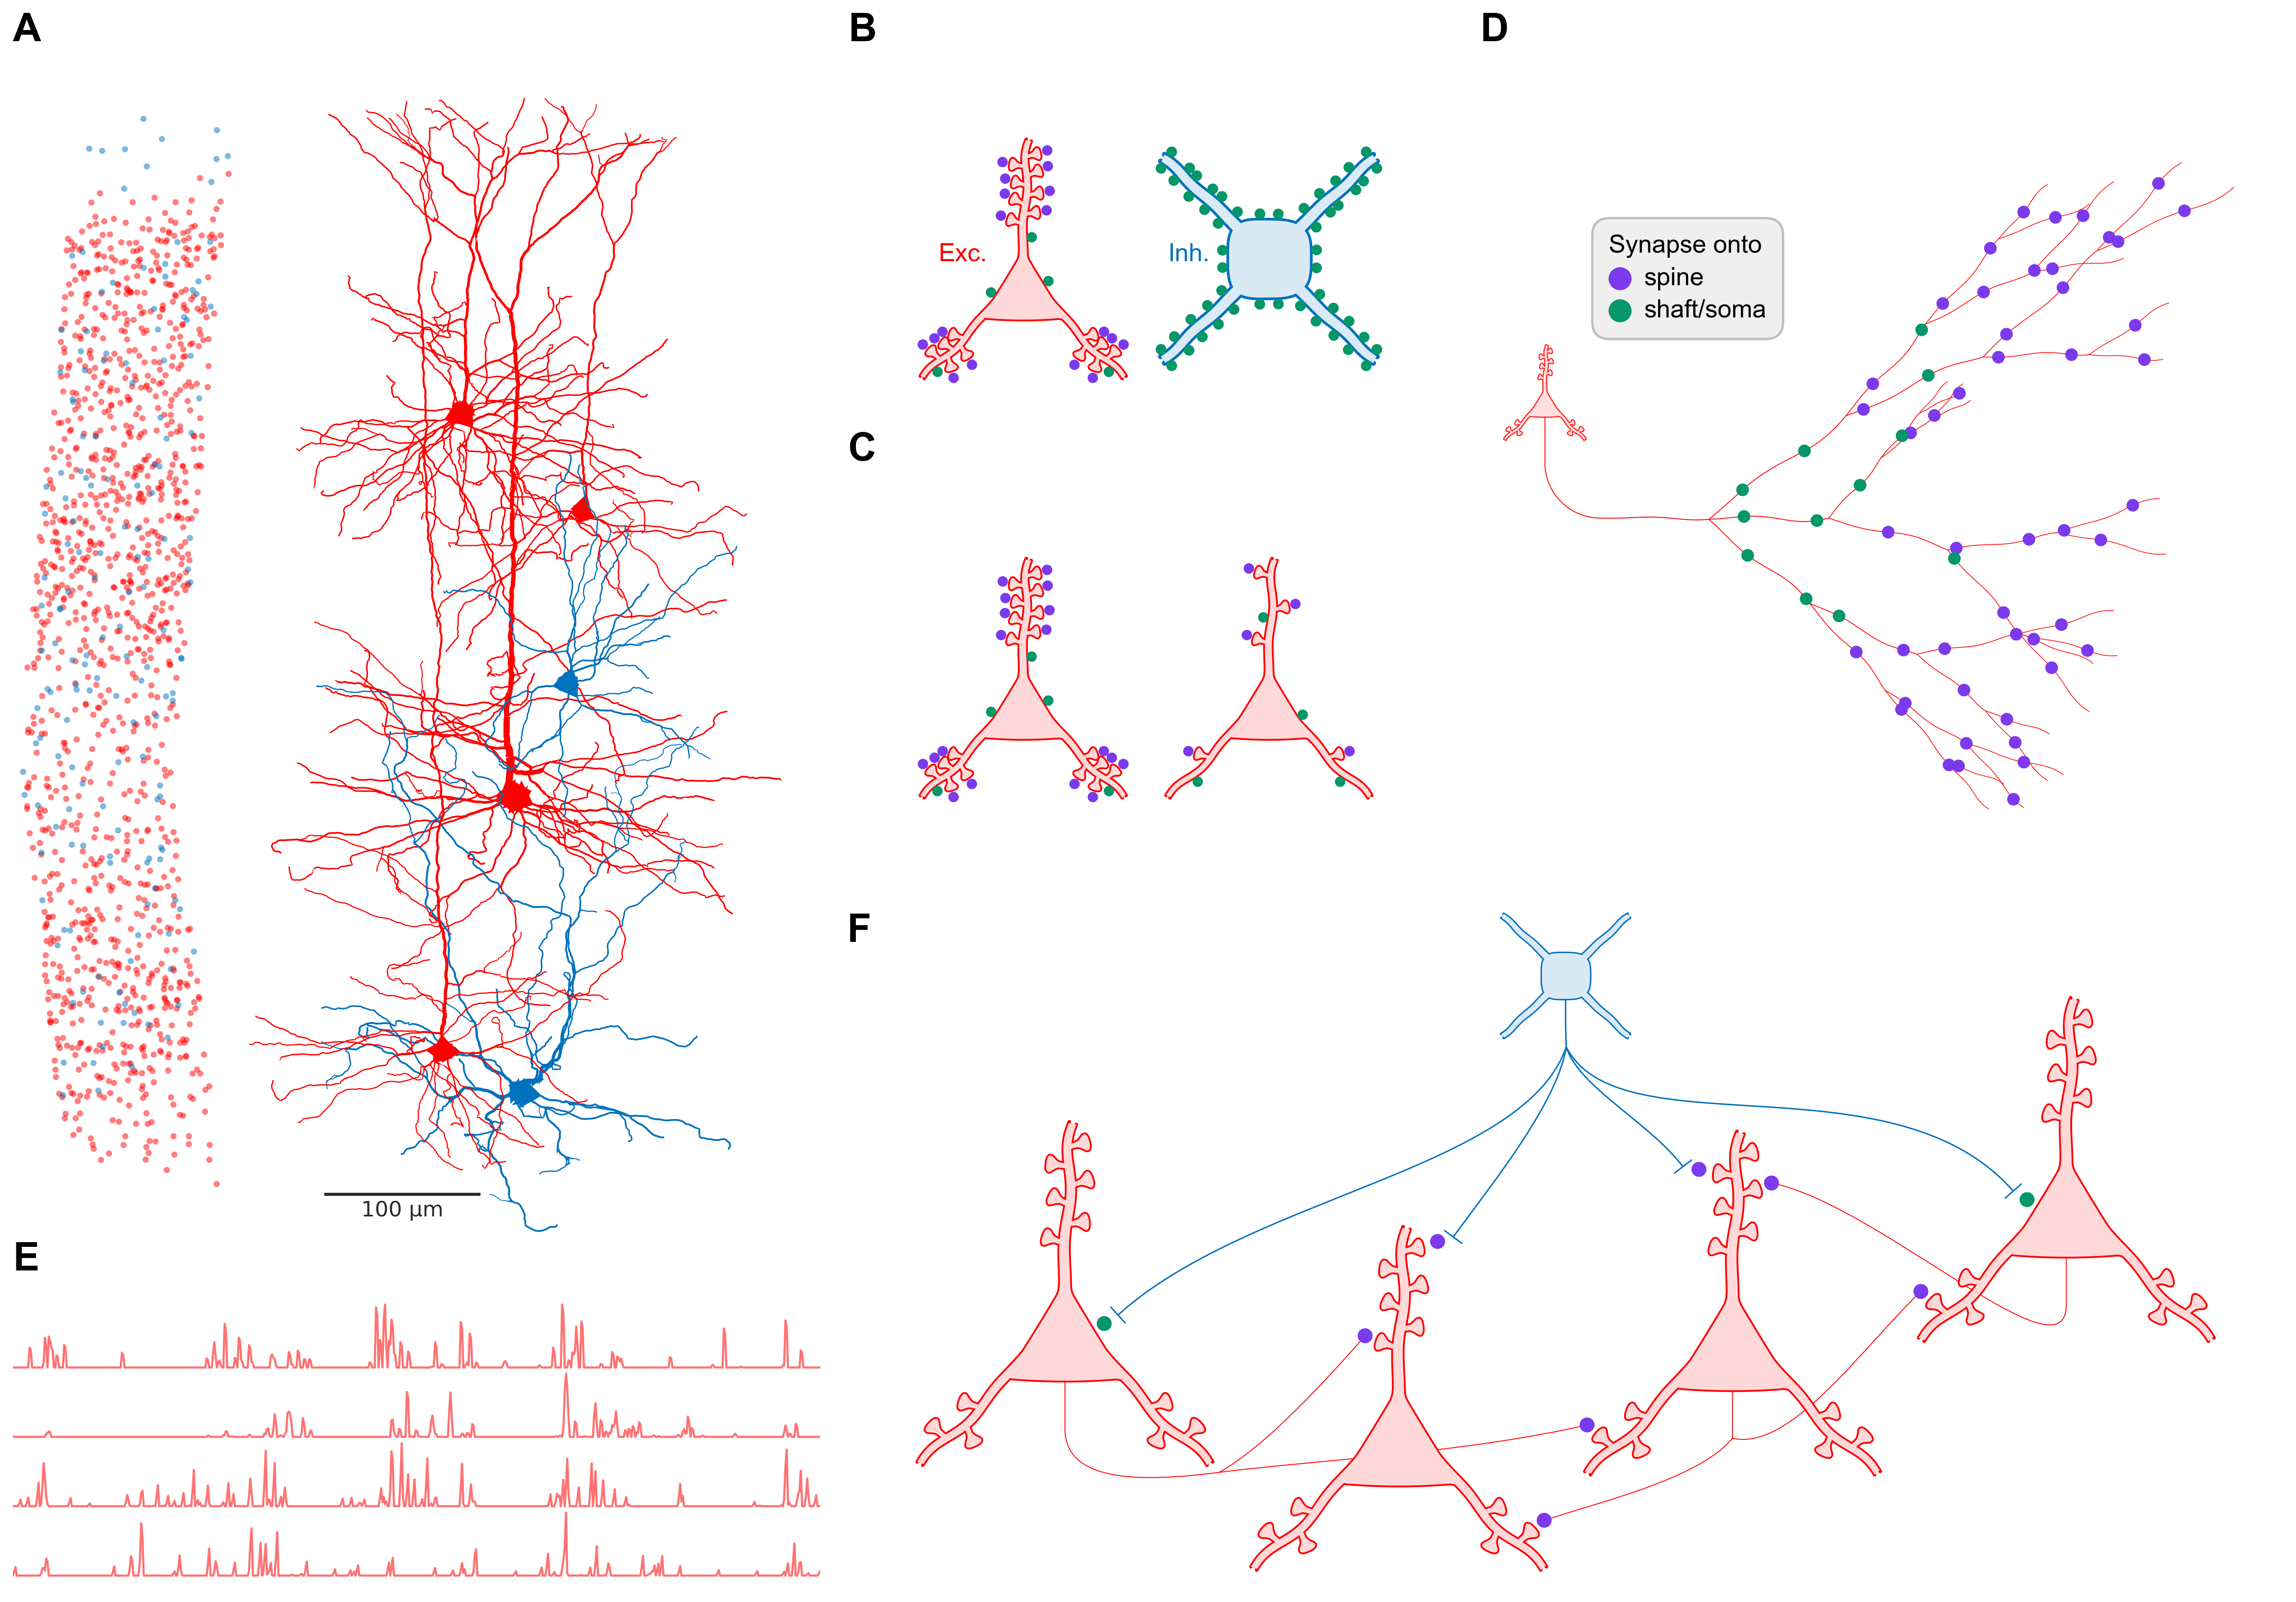

In [11]:
fig, axes, _ = plot_figure7_with_data(
    scatter_df=neurons_df, scatter_kw=FIG7_SCATTER_KW,
    cells_mode=CELLS_MODE, skeletons=skeletons, triangulations=mesh_triangs,
    cell_colors=column_colors, cells_kw=FIG7_CELLS_KW,
    traces=traces_4, trace_fps=trace_fps, traces_kw=FIG7_TRACES_KW,
    schematic_kw=SCHEMATIC_KW, **FIG7_DATA_LAYOUT)

plt.savefig('fig7.pdf', format='pdf', bbox_inches='tight')
